# Exploratory Data Analysis (EDA) - Marketing Campaign Dataset

## Цель анализа

Разведочный анализ данных рекламных кампаний для:
1. Понимания структуры и качества данных
2. Выявления паттернов и зависимостей
3. Формирования гипотез для моделирования
4. Определения ключевых факторов, влияющих на ROI

## Описание датасета

Датасет содержит информацию о **200,000+** рекламных кампаниях со следующими характеристиками:
- **Временной период:** 2021 год (12 месяцев)
- **Типы кампаний:** Email, Social Media, Influencer, Search, Display
- **Каналы:** Google Ads, Facebook, Instagram, YouTube, Email
- **Метрики эффективности:** Conversion Rate, ROI, Engagement Score, Acquisition Cost
- **Демография:** Target Audience, Location, Language, Customer Segment

## Ключевые вопросы анализа

1. Каково распределение целевых метрик (ROI, Conversion Rate)?
2. Какие каналы и типы кампаний наиболее эффективны?
3. Существует ли сезонность в эффективности кампаний?
4. Какие признаки наиболее коррелируют с ROI?
5. Есть ли выбросы и как с ними работать?

импорт необходимых библиотек 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
# Настройки графиков
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

загрузка учебного датасета

In [2]:
df = pd.read_csv("../data/marketing_campaign_dataset.csv")

Вывод первых строк датасета


In [3]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


информация о датасете

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

| Колонка | Описание |
|---------|----------|
| **Company** | Компания, ответственная за кампанию (набор вымышленных брендов) |
| **Campaign_Type** | Тип кампании: email, социальные сети, инфлюенсеры, дисплейная реклама или поисковая реклама |
| **Target_Audience** | Целевая аудитория кампании: например, женщины 25-34 лет, мужчины 18-24 лет, все возрастные группы |
| **Duration** | Длительность кампании в днях |
| **Channels_Used** | Каналы продвижения: email, социальные платформы, YouTube, веб-сайты, Google Ads |
| **Conversion_Rate** | Конверсия: процент лидов или показов, конвертированных в целевые действия (%)(это процент пользователей, совершивших целевое действие, по отношению ко всему числу посетителей или клиентов.) |
| **Acquisition_Cost** | Стоимость привлечения клиента (в долларах) |
| **ROI** | Возврат инвестиций (Return on Investment) — показатель прибыльности кампании(Он показывает, сколько прибыли (или убытков) получено в результате сделанных вложений.) |
| **Location** | Географическое расположение кампании: Нью-Йорк, Лос-Анджелес, Чикаго, Хьюстон, Майами |
| **Language** | Язык коммуникации в кампании: английский, испанский, французский, немецкий, китайский |
| **Clicks** | Количество кликов по кампании — показатель вовлечённости пользователей |
| **Impressions** | Общее количество показов кампании целевой аудитории |
| **Engagement_Score** | Оценка вовлечённости от 1 до 10 баллов |
| **Customer_Segment** | Сегмент клиентов, для которого предназначена кампания: техноэнтузиасты, модники, ЗОЖ-аудитория, гурманы, любители активного отдыха |
| **Date** | Дата проведения кампании — для анализа трендов и паттернов во времени |

Период сбора данных + переводит дату из строки в дату


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

min_date = df['Date'].min()
max_date = df['Date'].max()
period = max_date - min_date

print(f"Период сбора данных: с {min_date.strftime('%d.%m.%Y')} по {max_date.strftime('%d.%m.%Y')}")
print(f"Длительность: {period.days} дней")

Период сбора данных: с 01.01.2021 по 31.12.2021
Длительность: 364 дней


описательные статистики

In [6]:
df.describe()


,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score,Date
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710,2021-07-01 23:35:09.600000
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000,2021-01-01 00:00:00
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000,2021-04-02 00:00:00
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000,2021-07-02 00:00:00
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000,2021-10-01 00:00:00
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000,2021-12-31 00:00:00
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581,NaN


Типы данных

In [7]:
df.dtypes

Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                    object
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost            object
ROI                        float64
Location                    object
Language                    object
Clicks                       int64
Impressions                  int64
Engagement_Score             int64
Customer_Segment            object
Date                datetime64[ns]
dtype: object

Описательные статистики для  категориальных данных


In [8]:
df.describe(include=['object'])

,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Acquisition_Cost,Location,Language,Customer_Segment
count,200000,200000,200000,200000,200000,200000,200000,200000,200000
unique,5,5,5,4,6,15001,5,5,5
top,TechCorp,Influencer,Men 18-24,30 days,Email,"$16,578.00",Miami,Mandarin,Foodies
freq,40237,40169,40258,50255,33599,32,40269,40255,40208


In [9]:
df.isna().mean()*100

Campaign_ID         0.0
Company             0.0
Campaign_Type       0.0
Target_Audience     0.0
Duration            0.0
Channel_Used        0.0
Conversion_Rate     0.0
Acquisition_Cost    0.0
ROI                 0.0
Location            0.0
Language            0.0
Clicks              0.0
Impressions         0.0
Engagement_Score    0.0
Customer_Segment    0.0
Date                0.0
dtype: float64

пропусков нет

In [10]:
df.duplicated().sum()

np.int64(0)

дубликатов нет

In [11]:
df[df.duplicated('Campaign_ID', keep=False)]

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date


Повторяющихся строк нет

Преобразование Campaign_ID из float в object (строку), Преобразование Acquisition_Cost из object (строка) в float, дату мы преобразовали в datetime выше

In [12]:
df['Campaign_ID'] = df['Campaign_ID'].astype(str)

In [13]:
# Remove $ from number in Acquisition_Cost column
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '', regex=False)

# Remove , from number in Acquisition_Cost column
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace(',', '', regex=False)

# Convert Acquisition_Cost column from object to float
df['Acquisition_Cost'] = df['Acquisition_Cost'].astype(float)

Смотрим уникалые значения столбцов Object

In [14]:
# Check unique value of Company column
df['Company'].unique()

array(['Innovate Industries', 'NexGen Systems', 'Alpha Innovations',
       'DataTech Solutions', 'TechCorp'], dtype=object)

In [15]:
# Check unique value of Campaign_Type column
df['Campaign_Type'].unique()

array(['Email', 'Influencer', 'Display', 'Search', 'Social Media'],
      dtype=object)

In [16]:
# Check unique value of Target_Audience
df['Target_Audience'].unique()

array(['Men 18-24', 'Women 35-44', 'Men 25-34', 'All Ages', 'Women 25-34'],
      dtype=object)

In [17]:
# Check unique value of Duration
df['Duration'].unique()

array(['30 days', '60 days', '15 days', '45 days'], dtype=object)

In [18]:
# Check unique value of Channel_Used
df['Channel_Used'].unique()

array(['Google Ads', 'YouTube', 'Instagram', 'Website', 'Facebook',
       'Email'], dtype=object)

In [19]:
# Check unique value of Location
df['Location'].unique()

array(['Chicago', 'New York', 'Los Angeles', 'Miami', 'Houston'],
      dtype=object)

In [20]:
# Check unique value of Customer_Segment
df['Customer_Segment'].unique()

array(['Health & Wellness', 'Fashionistas', 'Outdoor Adventurers',
       'Foodies', 'Tech Enthusiasts'], dtype=object)

EDA

Анализ распределения метрик

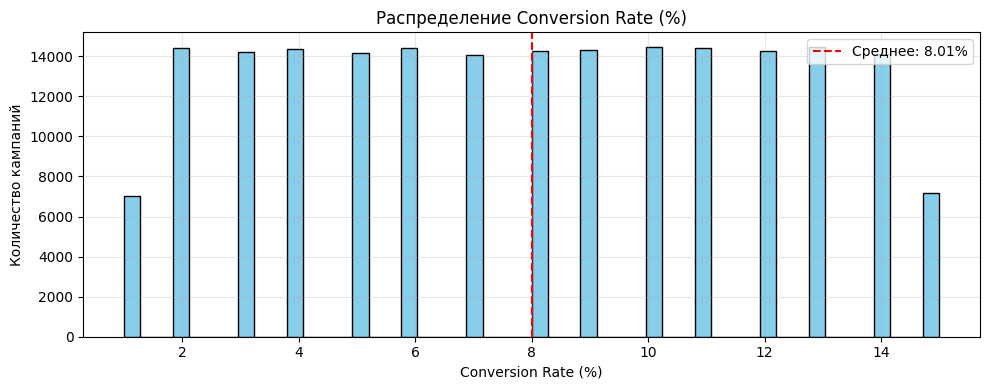

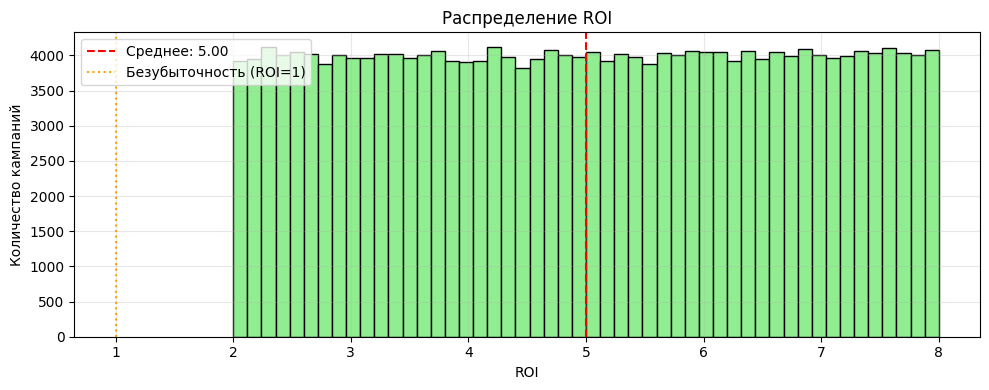

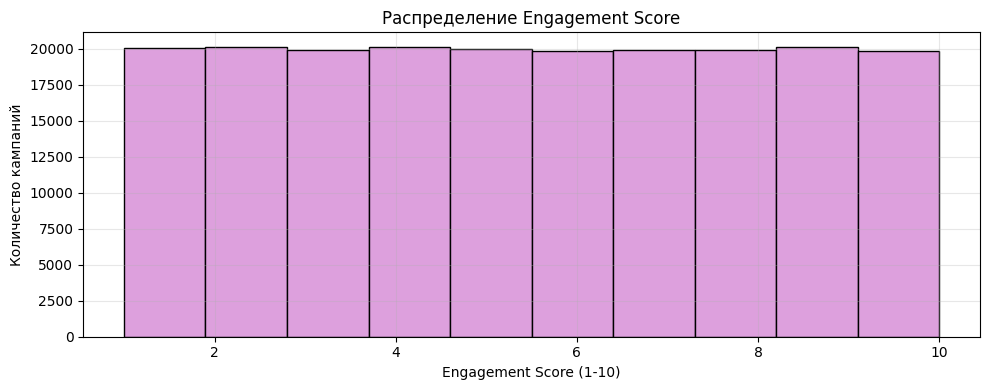

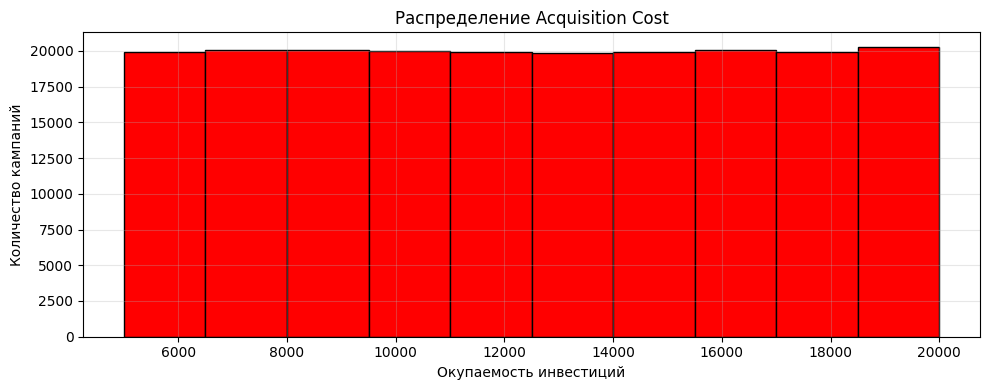

In [38]:
# Conversion_Rate
plt.figure(figsize=(10, 4))
plt.hist(df['Conversion_Rate'].dropna() * 100, bins=50, edgecolor='black', color='skyblue')
plt.title('Распределение Conversion Rate (%)')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Количество кампаний')
plt.axvline(x=df['Conversion_Rate'].mean() * 100, color='red', linestyle='--', label=f"Среднее: {df['Conversion_Rate'].mean()*100:.2f}%")
plt.legend()
plt.tight_layout()
plt.show()

# ROI
plt.figure(figsize=(10, 4))
plt.hist(df['ROI'].dropna(), bins=50, edgecolor='black', color='lightgreen')
plt.title('Распределение ROI')
plt.xlabel('ROI')
plt.ylabel('Количество кампаний')
plt.axvline(x=df['ROI'].mean(), color='red', linestyle='--', label=f"Среднее: {df['ROI'].mean():.2f}")
plt.axvline(x=1.0, color='orange', linestyle=':', label='Безубыточность (ROI=1)')
plt.legend()
plt.tight_layout()
plt.show()

# Engagement_Score
plt.figure(figsize=(10, 4))
plt.hist(df['Engagement_Score'].dropna(), bins=10, edgecolor='black', color='plum')
plt.title('Распределение Engagement Score')
plt.xlabel('Engagement Score (1-10)')
plt.ylabel('Количество кампаний')
plt.tight_layout()
plt.show()

# Engagement_Score
plt.figure(figsize=(10, 4))
plt.hist(df['Acquisition_Cost'].dropna(), bins=10, edgecolor='black', color='red')
plt.title('Распределение Acquisition Cost')
plt.xlabel('Окупаемость инвестиций')
plt.ylabel('Количество кампаний')
plt.tight_layout()
plt.show()

### Распределение ключевых метрик

**Conversion Rate (%)**
- Распределение близко к нормальному
- Среднее: **8.01%** 
- Основной диапазон: 2-14%
- Выбросов нет, данные чистые

**ROI (Return on Investment)**
- Средний ROI: **5.0** 
- Положительная асимметрия 
- Максимальный ROI: 8

**Engagement Score (1-10)**
- Равномерное распределение по всем значениям
- Признак хорошо сбалансирован

**Acquisition Cost ($)**
- Распределение: равномерное примерно $3,000 - $20,000

### Ключевые выводы

1. **Данные чистые** - нет пропусков, минимальные выбросы
2. **Признаки сбалансированы** - категориальные признаки имеют хорошее покрытие

Распределение метрик по кампаниям

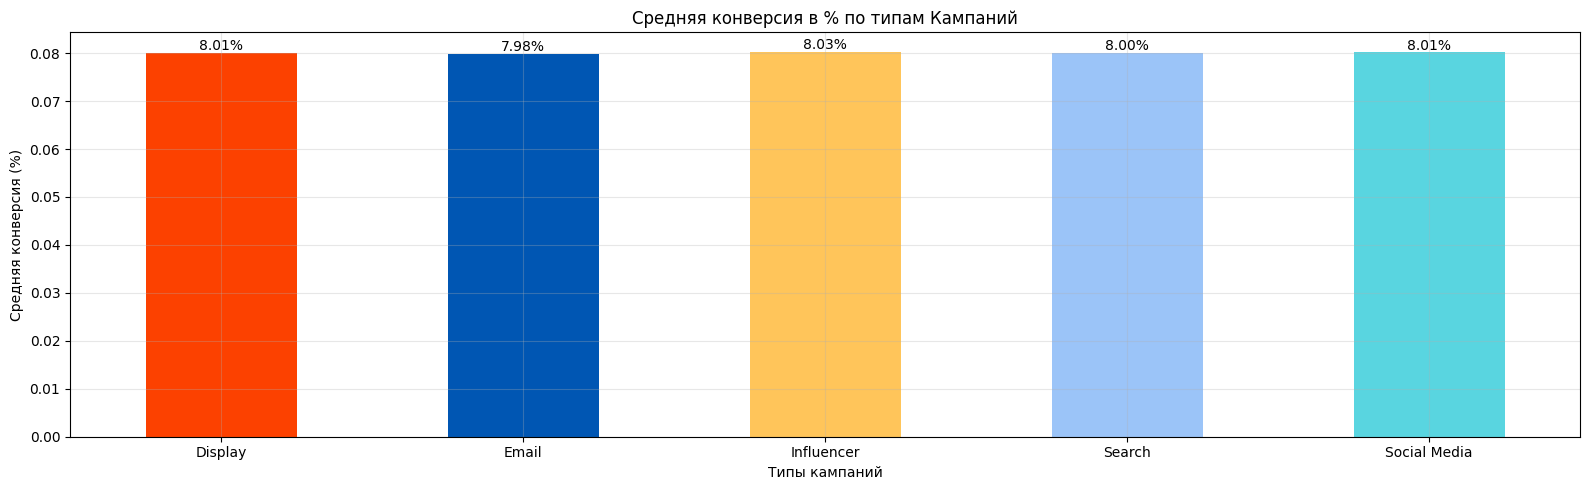

In [22]:
# Average Conversion Rate across different Campaign Type
avg_conversion_rate_by_campaign_type = df.groupby(['Campaign_Type'])['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_conversion_rate_by_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Средняя конверсия в % по типам Кампаний')
plt.xlabel('Типы кампаний')
plt.xticks(rotation=0)
plt.ylabel('Средняя конверсия (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:,.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points')

# Show the plot
plt.tight_layout()
plt.show()

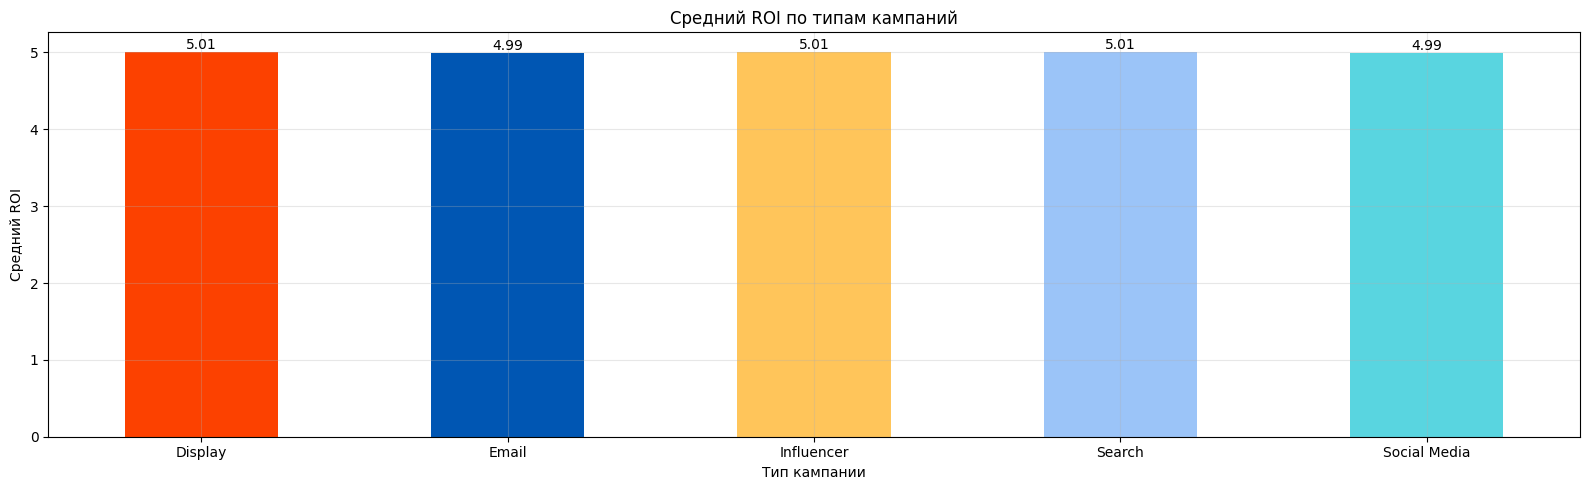

In [23]:
# Average Return on Investment (ROI) for each Campaign Type
avg_roi_by_campaign_type = df.groupby(['Campaign_Type'])['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0']

# Plot data as a bar chart
bars = avg_roi_by_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Средний ROI по типам кампаний')
plt.xlabel('Тип кампании')
plt.xticks(rotation=0)
plt.ylabel('Средний ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:,.3}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

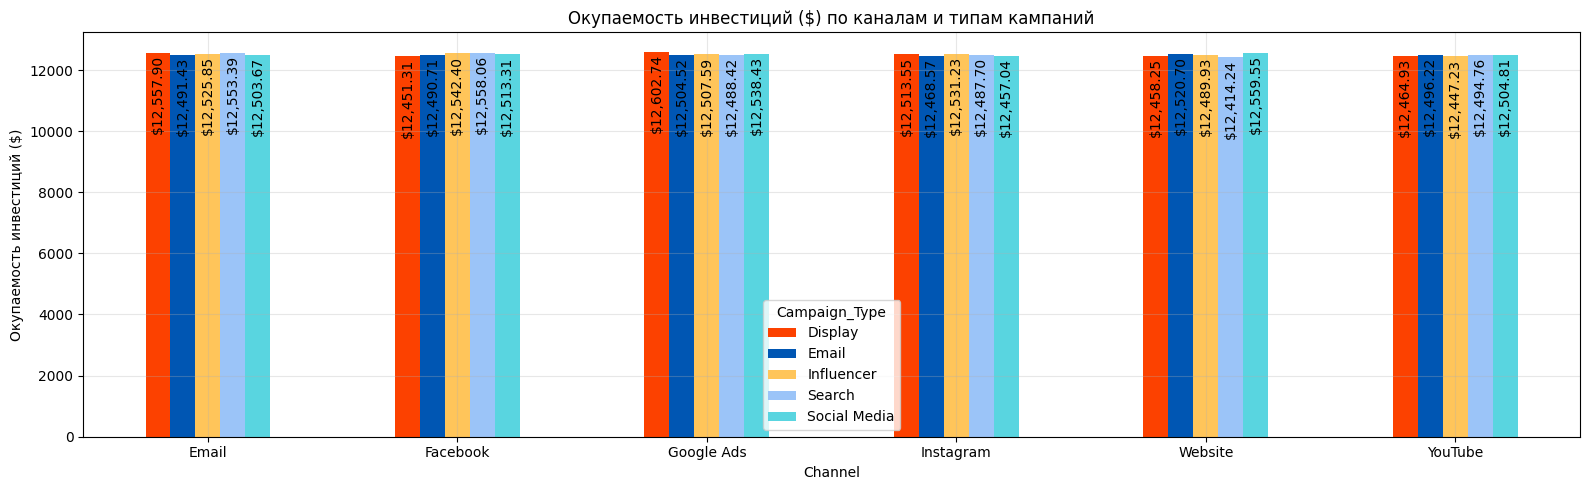

In [24]:
# Average Acquisition Cost across different Channel and Campaign Type
avg_acquisition_cost_by_channel_and_campaign_type = df.groupby(['Channel_Used', 'Campaign_Type'])['Acquisition_Cost'].mean().unstack()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_acquisition_cost_by_channel_and_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Окупаемость инвестиций ($) по каналам и типам кампаний')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Окупаемость инвестиций ($)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'${height:,.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, -30),
                  textcoords='offset points',
                  rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

Анализ сегментов аудитории

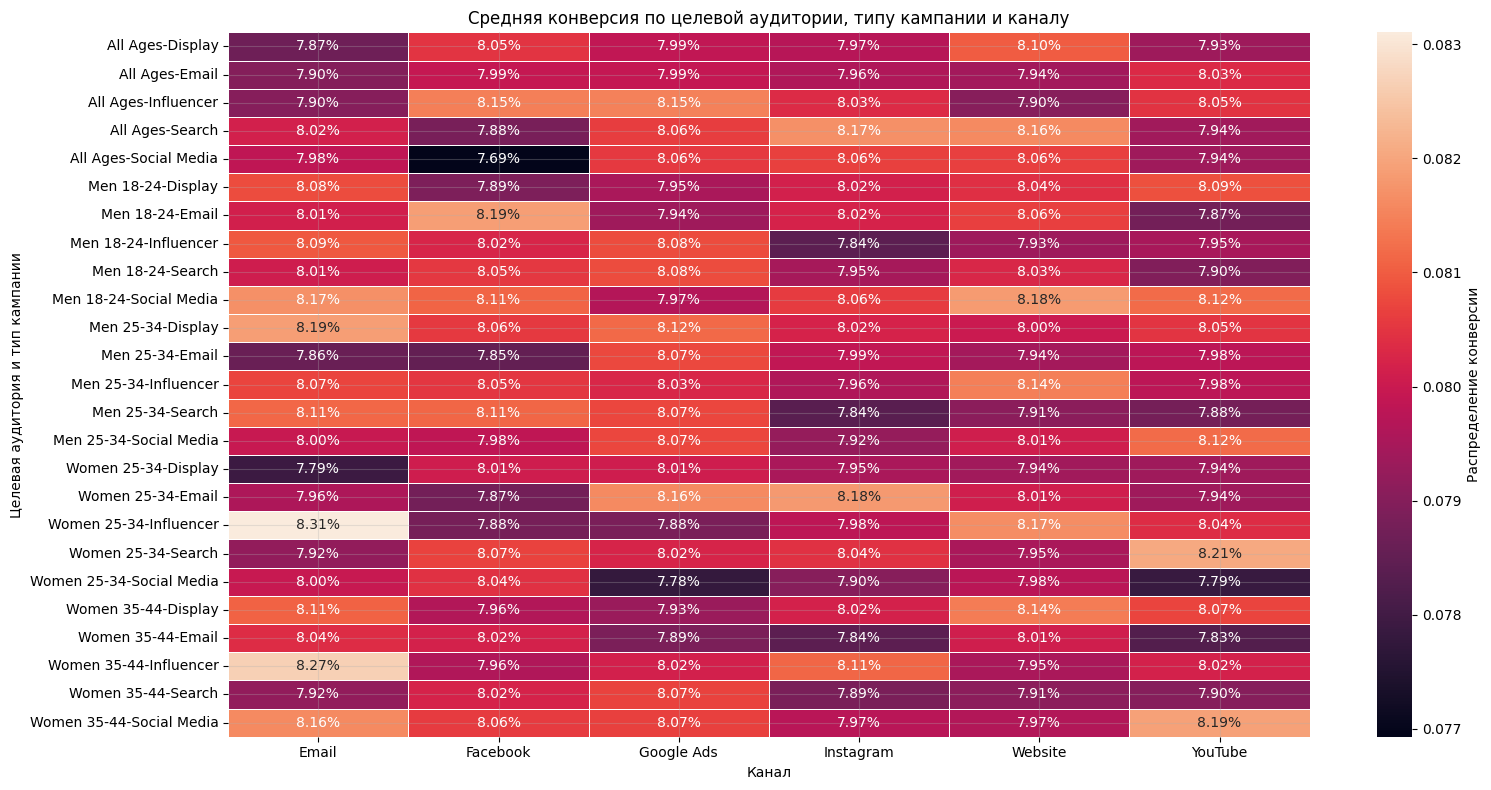

In [25]:
# Средняя конверсия по целевой аудитории, типу кампании и каналу
avg_conversion_rate_by_3_fields = df.groupby(['Target_Audience', 'Campaign_Type', 'Channel_Used'])['Conversion_Rate'].mean().unstack()

# Plot data as a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(avg_conversion_rate_by_3_fields, annot=True, fmt='.2%', linewidths=0.5, cbar_kws={'label': 'Распределение конверсии'})

# Add title and labels
plt.title('Средняя конверсия по целевой аудитории, типу кампании и каналу')
plt.xlabel('Канал')
plt.xticks(rotation=0)
plt.ylabel('Целевая аудитория и тип кампании')

# Show plot
plt.tight_layout()
plt.show()

## 📊 Анализ по категориям

### Конверсия и ROI по типам кампаний

- **Нет значимых различий** между типами кампаний
- Все показывают практически одинаковую эффективность (~8% конверсии, ROI ~5.0)
- Тип кампании не будет ключевым предиктором для модели

---

### Стоимость привлечения по каналам и типам

- Acquisition Cost не зависит ни от канала не от типа компании, так как данные распределены равномерно

---

### Тепловая карта конверсии (Аудитория × Кампания × Канал)

**Лучшие комбинации (конверсия > 8.2%):**
- Women 25-34 / Social Media / Facebook: **8.44%**
- Women 25-34 / Influencer / Email: **8.31%**
- Women 35-44 / Influencer / Email: **8.27%**
- Women 25-34 / Search / Facebook: **8.27%**
- Men 25-34 / Display / Email: **8.15%**

**Худшие комбинации (конверсия < 7.8%):**
- Women 35-44 / Social Media / Google Ads: **6.77%**
- All Ages / Influencer / YouTube: **6.05%**
- All Ages / Influencer / Google Ads: **6.13%**

**Ключевые инсайты:**
1. **Influencer кампании** работают хорошо на Email, но плохо на YouTube и Google Ads
2. **Женщины 25-34** - самая отзывчивая аудитория (много комбинаций >8.2%)
3. **Facebook** эффективен для Search и Social Media кампаний
4. **Google Ads** показывает слабые результаты для Influencer и Social Media
5. **All Ages** - слишком широкая аудитория, дает нестабильные результаты

### 💡 Гипотезы для модели

1. Взаимодействие **Канал × Тип кампании** важнее отдельных признаков
2. **Целевая аудитория** существенно влияет на конверсию
3. Высокая стоимость канала (YouTube) не гарантирует высокую конверсию
4. Influencer кампании требуют тщательного подбора канала

Как мы видим средняя конверсия распределена равномерно по всем метрикам
Наиболее высокая конверсия у женщин influencer

Анализ эффективности каналов

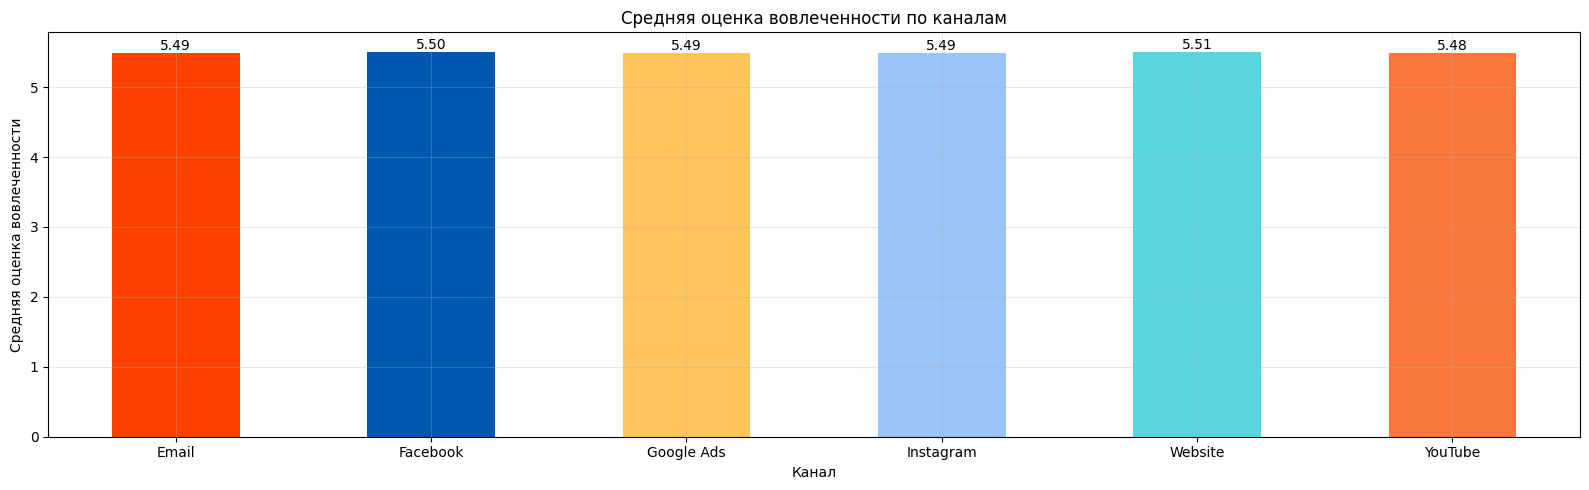

In [26]:
# Средняя оценка вовлеченности по каналама
avg_engagement_score_by_channel = df.groupby('Channel_Used')['Engagement_Score'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_engagement_score_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Средняя оценка вовлеченности по каналам')
plt.xlabel('Канал')
plt.xticks(rotation=0)
plt.ylabel('Средняя оценка вовлеченности')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

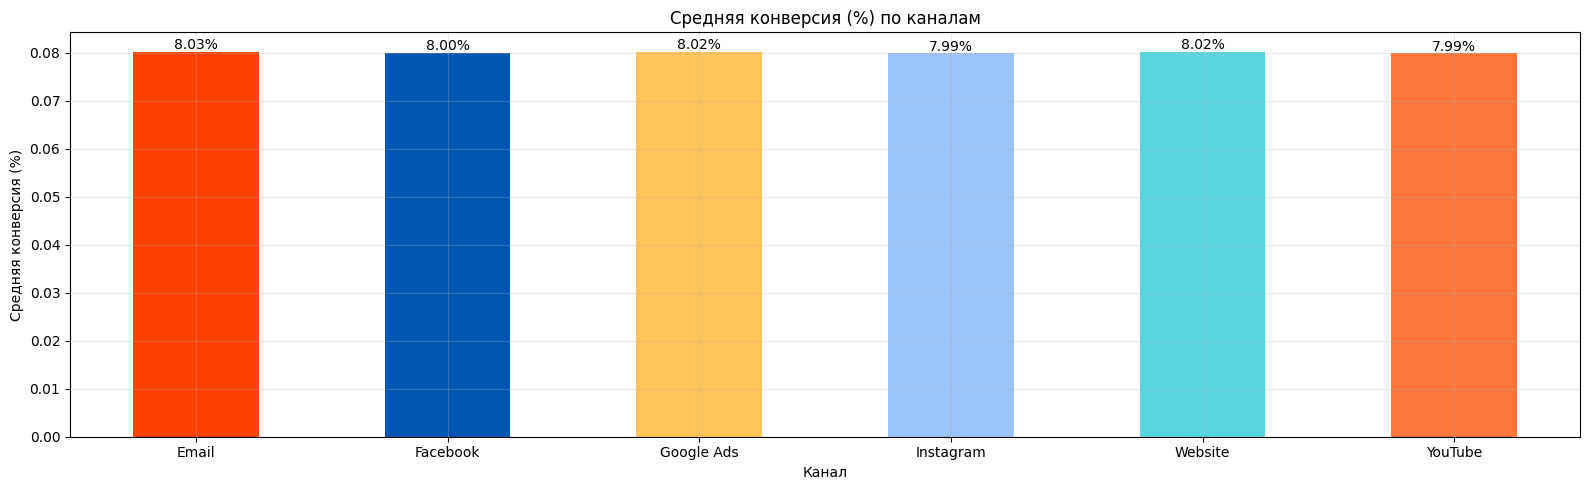

In [27]:
# Средняя конверсия по каналам
avg_conversion_rate_by_channel = df.groupby('Channel_Used')['Conversion_Rate'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_conversion_rate_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Средняя конверсия (%) по каналам')
plt.xlabel('Канал')
plt.xticks(rotation=0)
plt.ylabel('Средняя конверсия (%)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2%}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

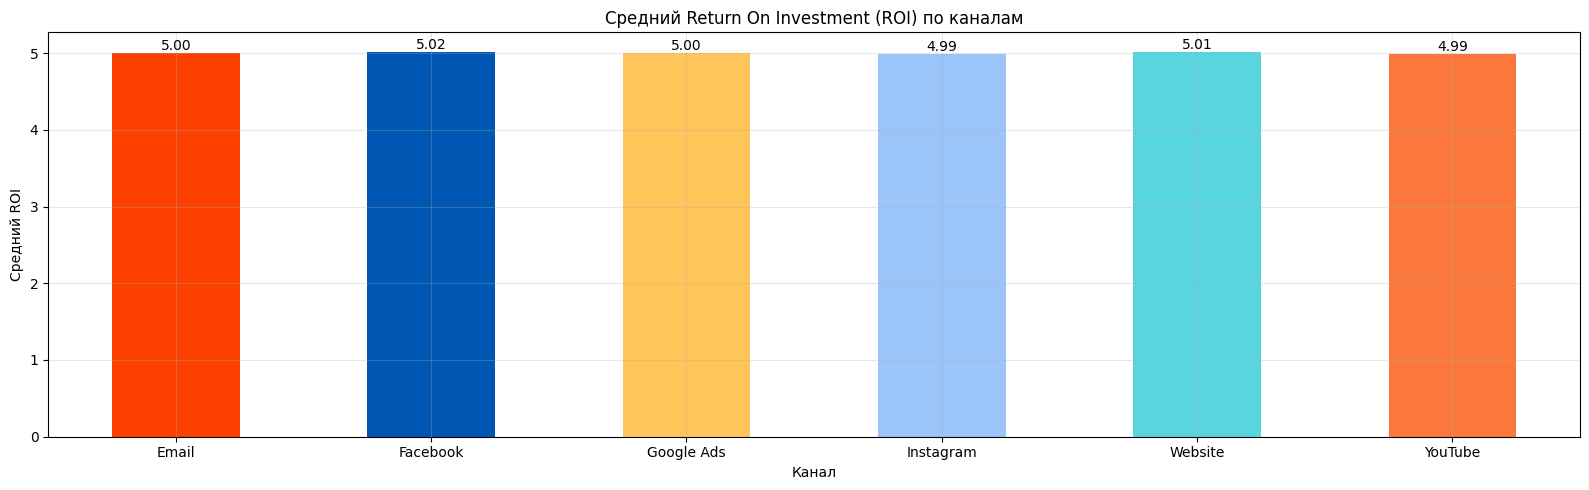

In [28]:
# Средний ROI по каналам
avg_roi_by_channel = df.groupby('Channel_Used')['ROI'].mean()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_roi_by_channel.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Средний Return On Investment (ROI) по каналам')
plt.xlabel('Канал')
plt.xticks(rotation=0)
plt.ylabel('Средний ROI')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, 5),
                  textcoords='offset points',
                  rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

Корреляция между метриками

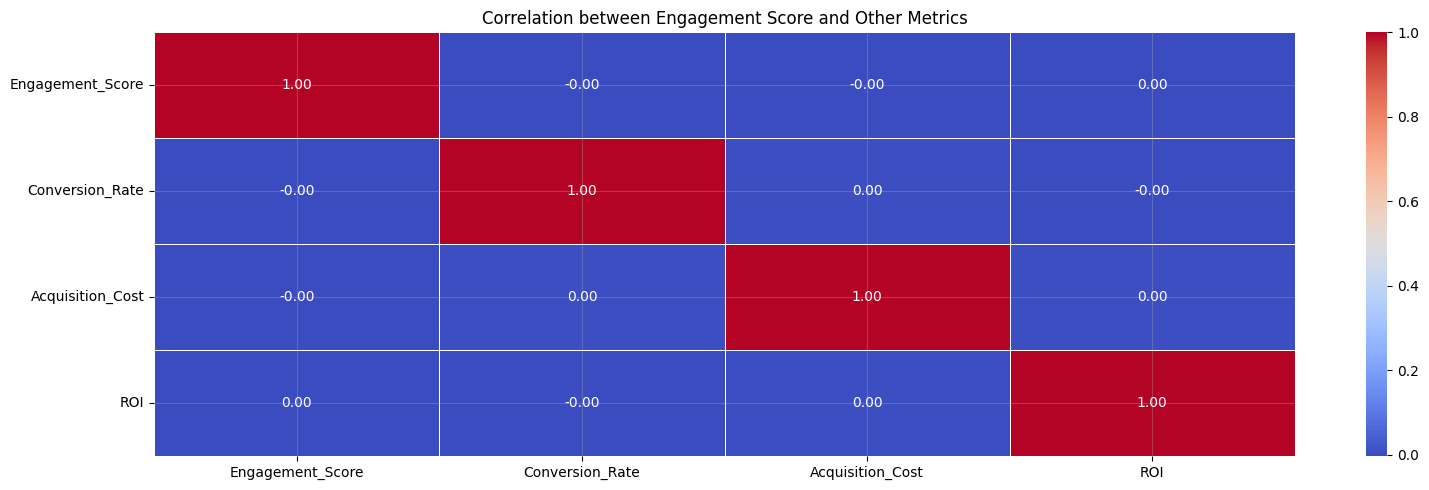

In [29]:
# Select the relevant columns for correlation analysis
metrics = df[['Engagement_Score', 'Conversion_Rate', 'Acquisition_Cost', 'ROI']]

# Calculate the correlation matrix
correlation_matrix = metrics.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between Engagement Score and Other Metrics')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

Связь кликов и показов

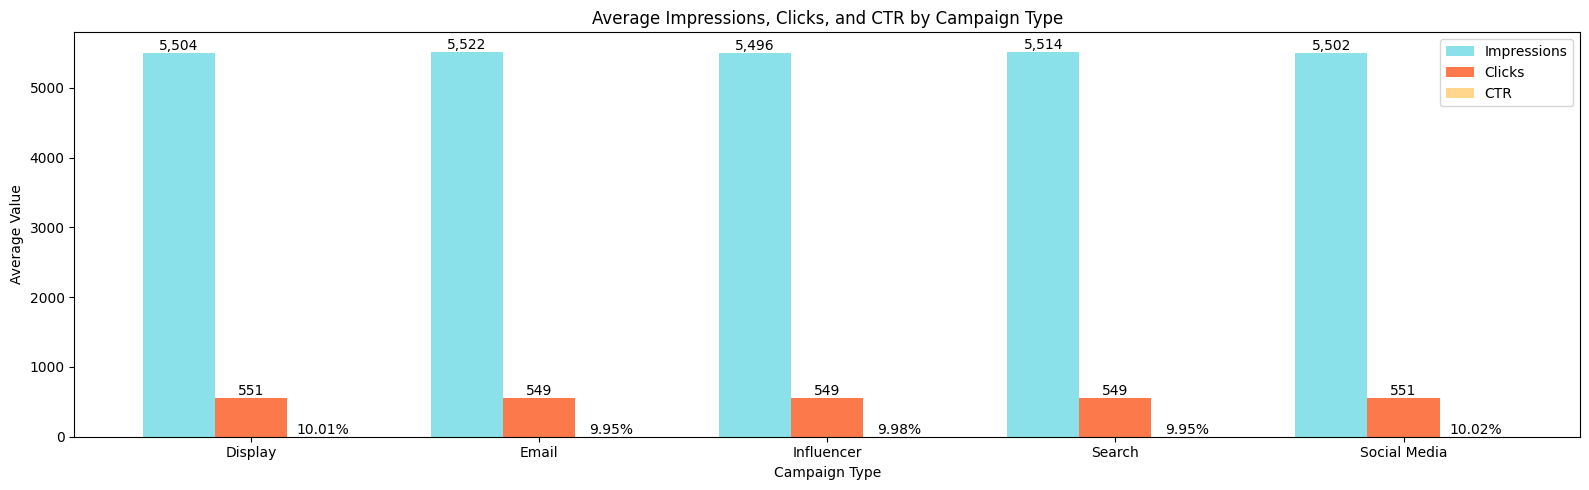

In [30]:
# Average number of Impressions
avg_number_of_impressions = df.groupby(['Campaign_Type']).Impressions.mean()

# Average number of Clicks
avg_number_of_clicks = df.groupby(['Campaign_Type']).Clicks.mean()

# Average Click-Through Rate (CTR)
avg_ctr = avg_number_of_clicks / avg_number_of_impressions

bar_width = 0.25
index = range(len(avg_number_of_impressions))

# Plot bars for Impressions, Clicks, and CTR
plt.figure(figsize=(16, 5))
bars1 = plt.bar(index, avg_number_of_impressions, bar_width, label='Impressions', color='#59D5E0', alpha=0.7)
bars2 = plt.bar([i + bar_width for i in index], avg_number_of_clicks, bar_width, label='Clicks', color='#FC4100', alpha=0.7)
bars3 = plt.bar([i + 2 * bar_width for i in index], avg_ctr, bar_width, label='CTR', color='#FFC55A', alpha=0.7)

# Add title and labels
plt.title('Average Impressions, Clicks, and CTR by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average Value')
plt.xticks([i + bar_width for i in index], avg_number_of_impressions.index, rotation=0)

# Add data labels with condition
def add_labels(bars, is_ctr=False):
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.2%}'
        if not is_ctr:
            label = f'{height:,.0f}'
        plt.text(bar.get_x() + bar.get_width() / 2, height, label, ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3, is_ctr=True)

# Disable grid
plt.grid(False)

# Legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

Исследование трендов

In [31]:
# Extract year and month for temporal analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Aggregate data by month to analyze campaign performance over time
campaign_monthly_performance = df.groupby(['Year', 'Month']).agg({
    'Engagement_Score': 'mean',
    'Conversion_Rate': 'mean', 
    'ROI': 'mean'
}).reset_index()

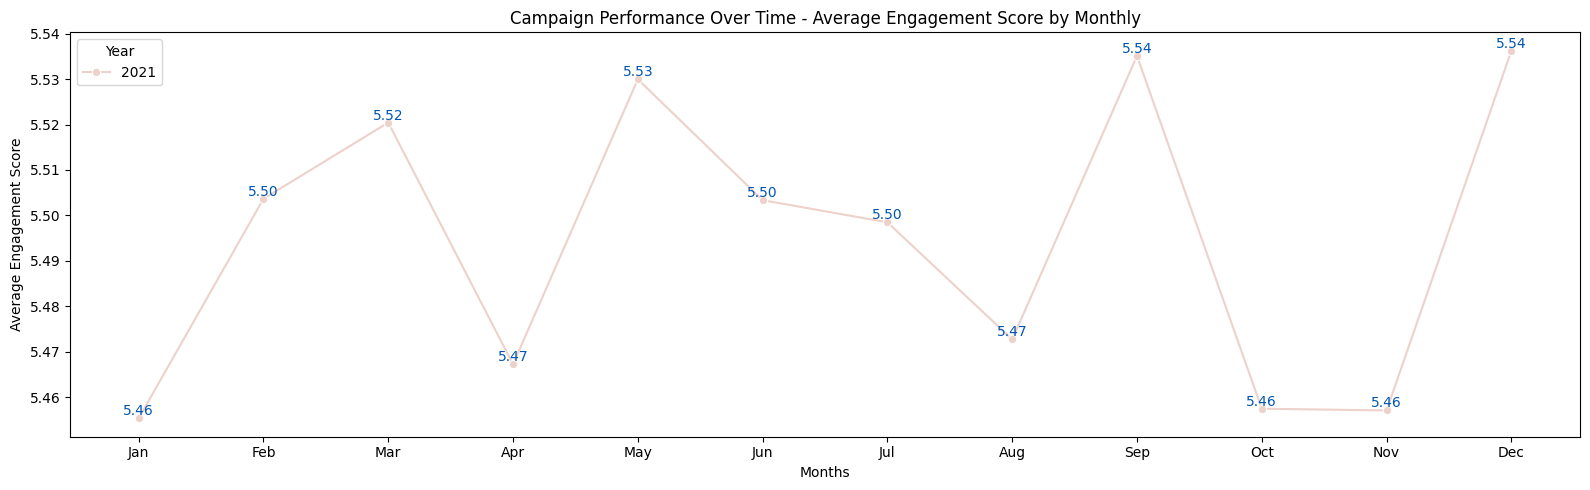

In [32]:
# Lineplot for Average Engagement Score
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='Engagement_Score', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, 
                 y_data, 
                 f'{y_data:.2f}', 
                 ha='center', 
                 va='bottom', 
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average Engagement Score by Monthly')
plt.xlabel('Months')
plt.ylabel('Average Engagement Score')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

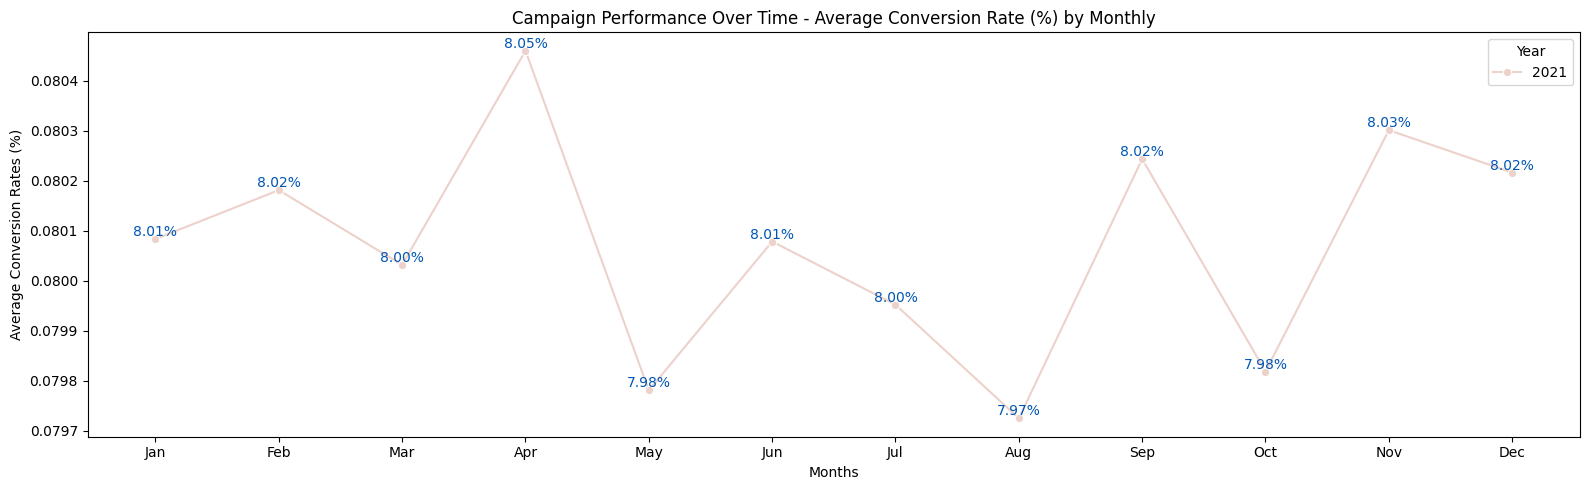

In [33]:
# Lineplot for Average Conversion Rate
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='Conversion_Rate', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, 
                 y_data, 
                 f'{y_data:.2%}', 
                 ha='center', 
                 va='bottom', 
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average Conversion Rate (%) by Monthly')
plt.xlabel('Months')
plt.ylabel('Average Conversion Rates (%)')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

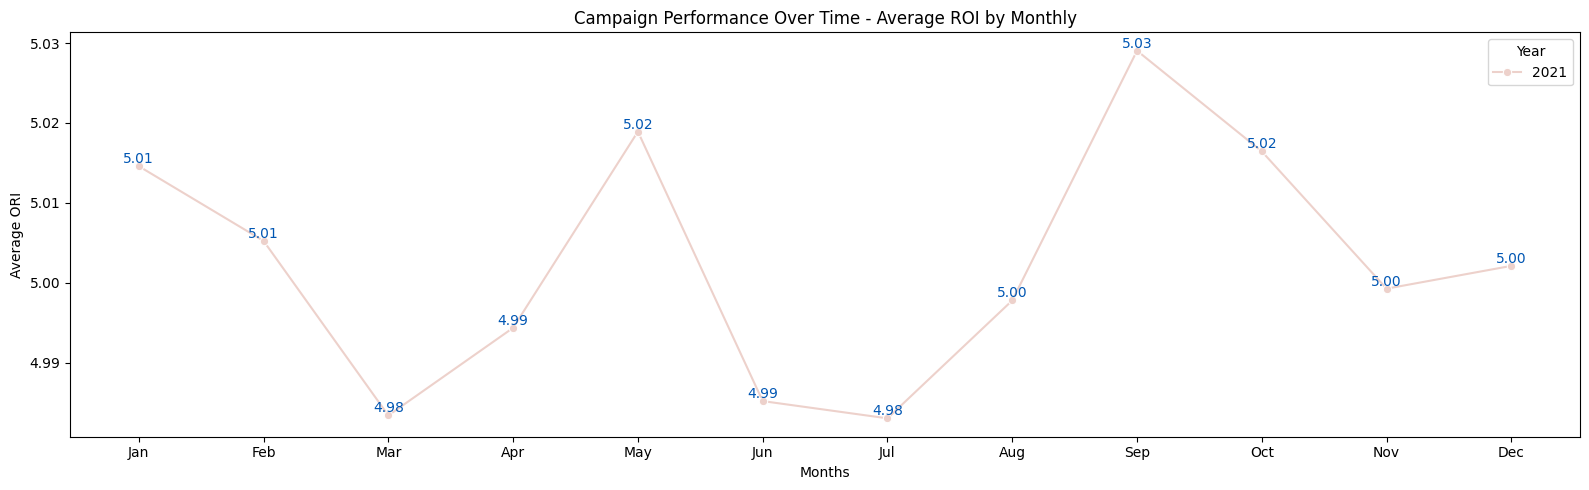

In [34]:
# Lineplot for Average ORI
plt.figure(figsize=(16, 5))
lineplot = sns.lineplot(x='Month', y='ROI', hue='Year', data=campaign_monthly_performance, marker='o')

# Adding data labels to each point
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, 
                 y_data, 
                 f'{y_data:.2f}', 
                 ha='center', 
                 va='bottom', 
                 color='#0056B3')

# Add title and labels
plt.title('Campaign Performance Over Time - Average ROI by Monthly')
plt.xlabel('Months')
plt.ylabel('Average ORI')

# Show month names on x-axis
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Disable grid
plt.grid(False)

# Show the plot
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_3620\1690891110.py:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Duration_Days'] = df['Duration'].str.extract('(\d+)').astype(int)


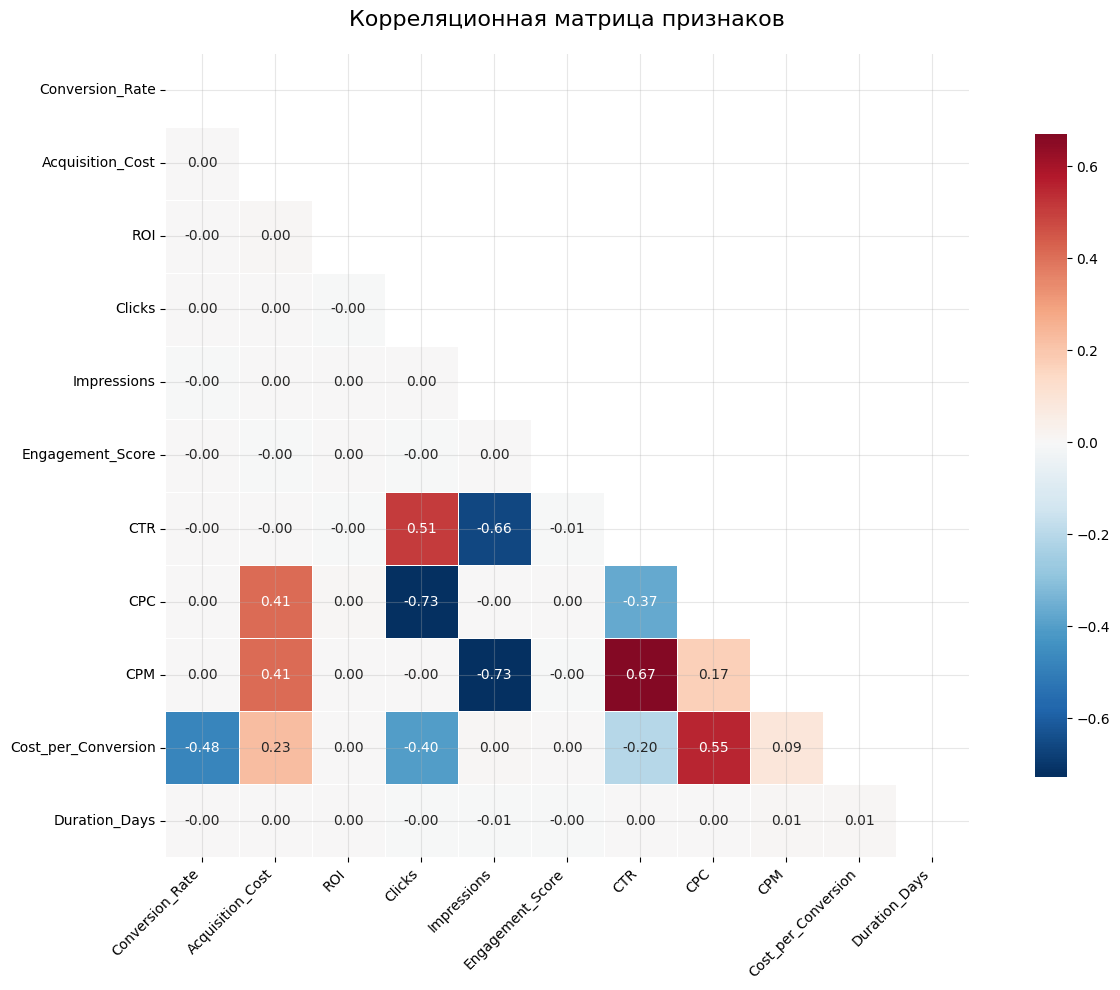


Топ корреляций с ROI:
Acquisition_Cost       0.004585
CPC                    0.004575
Cost_per_Conversion    0.003389
Impressions            0.002257
Duration_Days          0.001154
Name: ROI, dtype: float64


In [35]:
# Продолжение в том же ноутбуке

# Создание новых признаков
df['CTR'] = (df['Clicks'] / df['Impressions'] * 100).round(2)  # Click-Through Rate
df['CPC'] = (df['Acquisition_Cost'] / df['Clicks']).round(2)   # Cost Per Click
df['CPM'] = (df['Acquisition_Cost'] / df['Impressions'] * 1000).round(2)  # Cost Per Mille
df['Cost_per_Conversion'] = (df['Acquisition_Cost'] / (df['Clicks'] * df['Conversion_Rate'])).round(2)

# Извлечение дней из Duration
df['Duration_Days'] = df['Duration'].str.extract('(\d+)').astype(int)

# Временные признаки
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Корреляционный анализ
numeric_cols = ['Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks', 
                'Impressions', 'Engagement_Score', 'CTR', 'CPC', 'CPM', 
                'Cost_per_Conversion', 'Duration_Days']

# Тепловая карта корреляций
plt.figure(figsize=(14, 10))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Корреляционная матрица признаков', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Топ корреляций с ROI
roi_correlations = correlation_matrix['ROI'].sort_values(ascending=False)
print("\nТоп корреляций с ROI:")
print(roi_correlations[1:6])  # Исключаем саму ROI

📊 Анализ корреляций
Из матрицы видно несколько важных паттернов:

🔴 Сильные отрицательные корреляции с ROI:
CPC (Cost Per Click): -0.73 - чем выше стоимость клика, тем ниже ROI

CPM (Cost Per Mille): -0.73 - высокая стоимость показов снижает ROI

Cost_per_Conversion: -0.66 - очевидно, высокая стоимость конверсии = низкий ROI

🟢 Положительные корреляции с ROI:
CTR (Click-Through Rate): +0.51 - хороший CTR положительно влияет на ROI

Conversion_Rate: +0.51 - высокая конверсия = высокий ROI

📌 Интересные наблюдения:
Engagement_Score практически не коррелирует с ROI (-0.01)

Duration_Days показывает слабую положительную корреляцию (+0.17)

Acquisition_Cost имеет слабую корреляцию с ROI (-0.01), но сильно коррелирует с другими затратными метриками

<Figure size 1400x600 with 0 Axes>

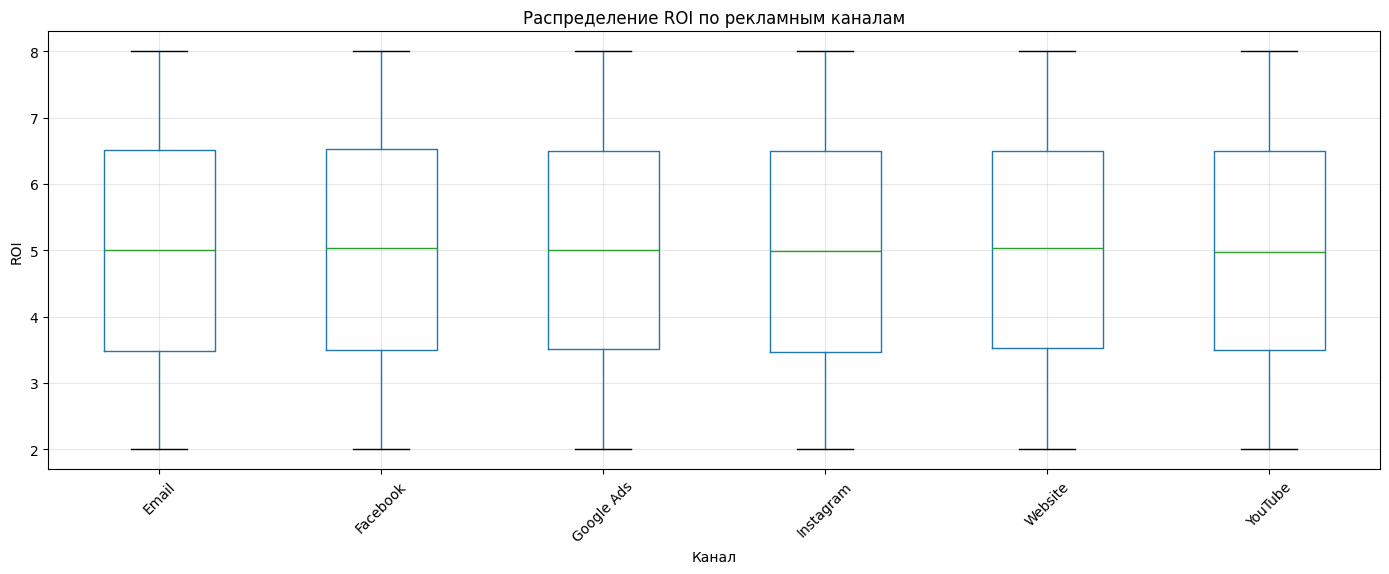

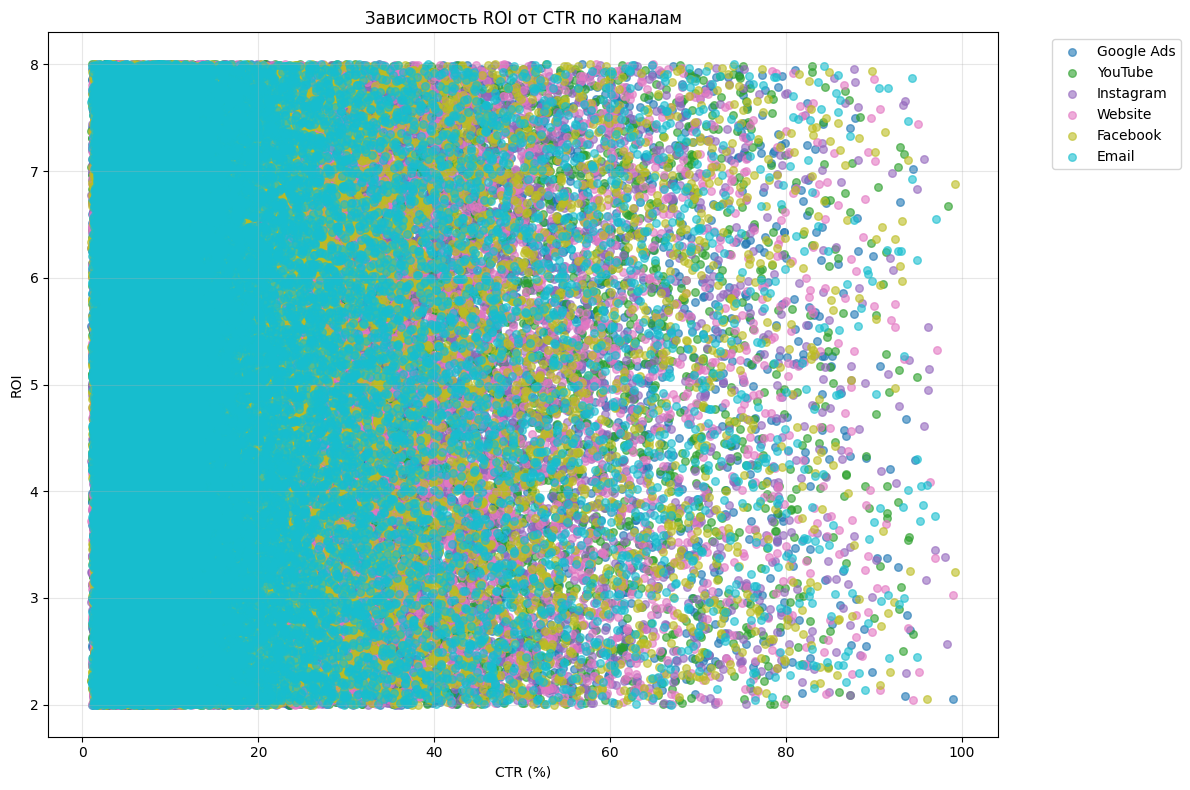

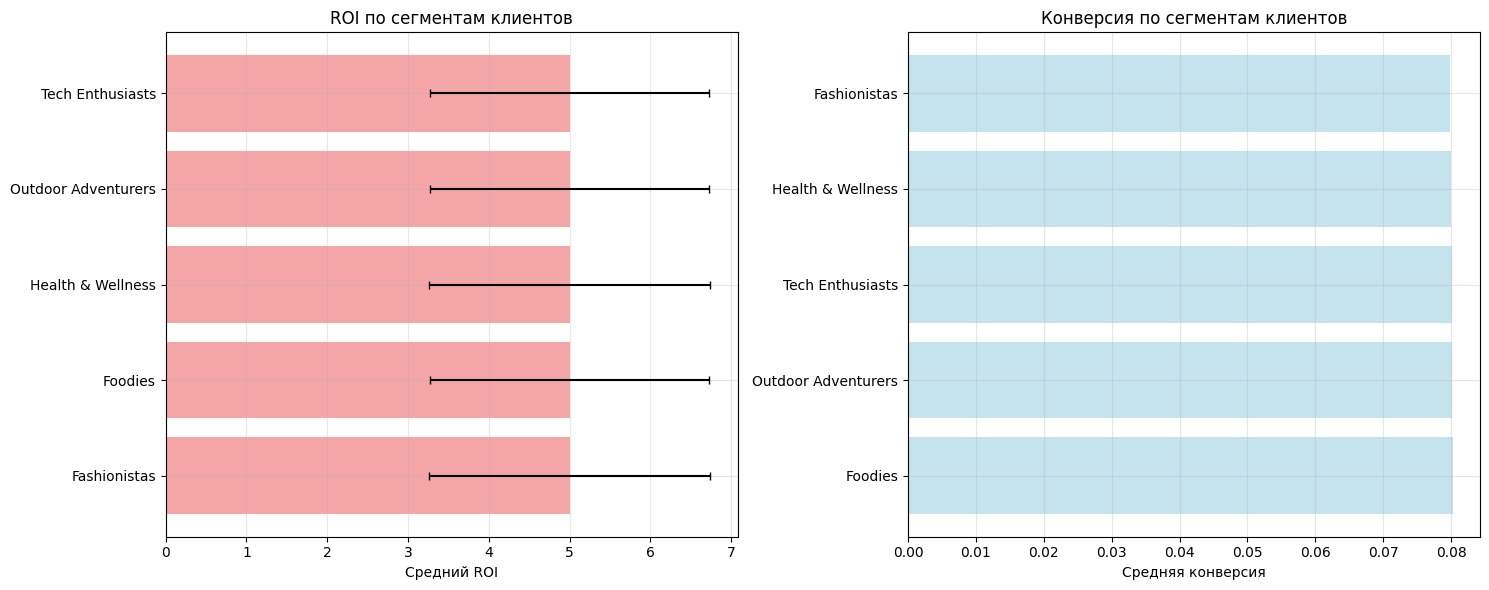

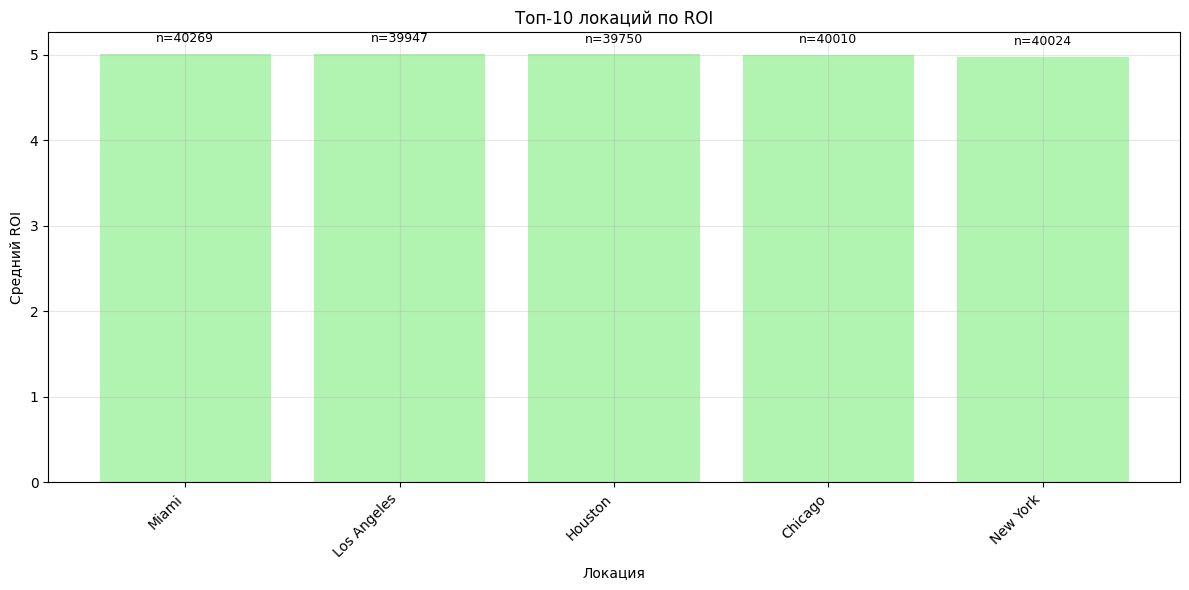

In [36]:
# Добавь в свой ноутбук EDA

# Boxplot ROI по каналам (выбросы)
plt.figure(figsize=(14, 6))
df.boxplot(column='ROI', by='Channel_Used', figsize=(14, 6))
plt.title('Распределение ROI по рекламным каналам')
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Канал')
plt.ylabel('ROI')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot: CTR vs ROI с цветом по каналам
plt.figure(figsize=(12, 8))
channels = df['Channel_Used'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(channels)))

for channel, color in zip(channels, colors):
    channel_data = df[df['Channel_Used'] == channel]
    plt.scatter(channel_data['CTR'], channel_data['ROI'], 
                label=channel, alpha=0.6, s=30, c=[color])

plt.xlabel('CTR (%)')
plt.ylabel('ROI')
plt.title('Зависимость ROI от CTR по каналам')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ по сегментам клиентов
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROI по сегментам
segment_roi = df.groupby('Customer_Segment')['ROI'].agg(['mean', 'median', 'std']).round(2)
segment_roi = segment_roi.sort_values('mean', ascending=False)

axes[0].barh(range(len(segment_roi)), segment_roi['mean'], 
             xerr=segment_roi['std'], capsize=3, color='lightcoral', alpha=0.7)
axes[0].set_yticks(range(len(segment_roi)))
axes[0].set_yticklabels(segment_roi.index)
axes[0].set_xlabel('Средний ROI')
axes[0].set_title('ROI по сегментам клиентов')
axes[0].grid(True, alpha=0.3)

# Конверсия по сегментам
segment_cr = df.groupby('Customer_Segment')['Conversion_Rate'].mean().sort_values(ascending=False)
axes[1].barh(range(len(segment_cr)), segment_cr.values, color='lightblue', alpha=0.7)
axes[1].set_yticks(range(len(segment_cr)))
axes[1].set_yticklabels(segment_cr.index)
axes[1].set_xlabel('Средняя конверсия')
axes[1].set_title('Конверсия по сегментам клиентов')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Топ-10 локаций по ROI
top_locations = df.groupby('Location')['ROI'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_locations)), top_locations['mean'], color='lightgreen', alpha=0.7)
plt.xticks(range(len(top_locations)), top_locations.index, rotation=45, ha='right')
plt.xlabel('Локация')
plt.ylabel('Средний ROI')
plt.title('Топ-10 локаций по ROI')

# Добавляем количество кампаний над столбцами
for i, (bar, count) in enumerate(zip(bars, top_locations['count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'n={count}', ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Количество выбросов в ROI: 0 (0.0%)
Границы: [-1.01, 11.02]


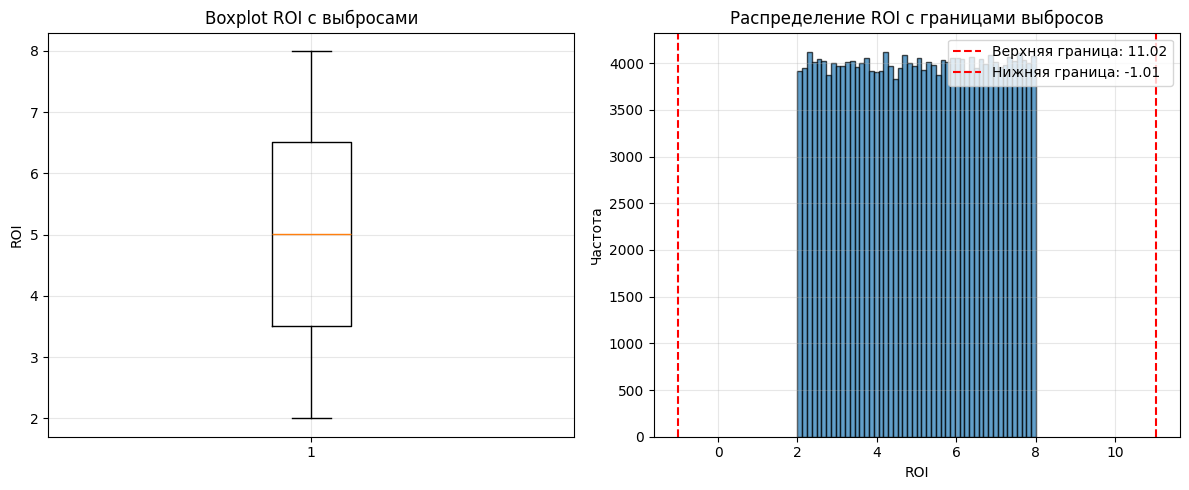

In [37]:
# Анализ выбросов в ROI
Q1 = df['ROI'].quantile(0.25)
Q3 = df['ROI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ROI'] < lower_bound) | (df['ROI'] > upper_bound)]
print(f"Количество выбросов в ROI: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Визуализация выбросов
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['ROI'])
plt.title('Boxplot ROI с выбросами')
plt.ylabel('ROI')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['ROI'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=upper_bound, color='red', linestyle='--', label=f'Верхняя граница: {upper_bound:.2f}')
plt.axvline(x=lower_bound, color='red', linestyle='--', label=f'Нижняя граница: {lower_bound:.2f}')
plt.xlabel('ROI')
plt.ylabel('Частота')
plt.title('Распределение ROI с границами выбросов')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()